# Horizon-Aware UWM — Diagnostic Eval (Tier 1)

Companion to the model trained by `scripts/train_dynamics_uwm_new.py` + `dreamerv4uwm/loss_new.py`.
Uses the self-contained diagnostic samplers in `dreamerv4uwm/sampling_new.py` (does not import from the legacy `sampling.py`).

Tier 1 — the diagnostics that directly test what the new training is supposed to do:
1. **Loss surface** on the (n_act, n_state) noise square — where is the model competent?
2. **θ-sweep rollouts** — does behavior smoothly interpolate between ID, policy, and WM?
3. **Mode 3 (random action proposer)** — does noisy-context joint generation produce diverse, coherent rollouts?
4. **Horizon-aware ablation** — does bidirectional attention within the horizon block help?

Convention reminder: `n` = noise level (0 clean, 1 noise — user-facing), `τ` = 1 - n (codebase). Sampler args expose `n`.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
import math
import torch
import numpy as np
import mediapy
import matplotlib.pyplot as plt
from torch.nn.functional import interpolate

from hydra import initialize, compose
from omegaconf import OmegaConf

from dreamerv4uwm.models.utils import load_tokenizer, load_denoiser
from dreamerv4uwm.datasets import G1ChunkDataset, ShardedHDF5Dataset
from dreamerv4uwm.sampling_new import (
    make_is_horizon,
    ray_sampler,
    grid_loss_probe,
)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
resolution = (256, 256)

In [3]:
# Config
with initialize(version_base=None, config_path='scripts/config'):
    cfg = compose(config_name='dynamics/ogbench-manipulation')
print('horizon_aware:', cfg.denoiser.get('horizon_aware', False))
print('train.unified.mode_probs:', OmegaConf.to_container(cfg.train.unified.mode_probs))

horizon_aware: False
train.unified.mode_probs: {'unified': 0.333, 'video_pretraining': 0.333, 'action_pretraining': 0.333}


/ext3/miniconda/envs/dreamerv4/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/ogbench-manipulation': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [4]:
# Point these at the new-pipeline checkpoint and the matching tokenizer.
DYNAMICS_CKPT = '/scratch/rk4342/projects/dreamerV4-UWM/checkpoints/dynamics/benchmarks/ogbench/manipulation/play-uwm/60000.pt'
TOKENIZER_CKPT = '/scratch/rk4342/projects/dreamerV4-UWM/checkpoints/tokenizer/ogbench-manipulation/23000.pt'
cfg.dynamics_ckpt = DYNAMICS_CKPT
cfg.tokenizer_ckpt = TOKENIZER_CKPT

denoiser = load_denoiser(cfg, device, max_num_forward_steps=300).eval().cuda()
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300).eval().cuda()
print(denoiser.model.frame_id_embedder)  # should be DiscreteEmbedder(2, model_dim) when horizon_aware=true

None


In [5]:
# A single held-out window for diagnostics.
import mediapy
from torch.nn.functional import interpolate

DATA_PATH = "/scratch/rk4342/datasets/benchmarks/ogbench/manipulation/visual-puzzle-3x3-v0"
dataset = ShardedHDF5Dataset(
        data_dir=DATA_PATH,
        window_size=64,
        stride=1,
        split='train',
        train_fraction=0.9,
        split_seed=123,
    )

# Arbitrary index into that episode
batch = dataset[torch.randint(len(dataset), (1,)).item()]
# imgs = batch["image"][:,[2, 1, 0], :, :]  # (T, C, H, W)
imgs = batch["image"]  # (T, C, H, W)
actions = batch["action"][:,:cfg.denoiser.n_actions][None].cuda()  # (1, T, N_lat, D_lat)
imgs = interpolate(imgs, resolution).to(device=device)[None] # resize to tokenizer resolution

with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        latents = tokenizer.encode(imgs)
        imgs_recon = tokenizer.decode(latents)

print('imgs:', imgs.shape, 'actions:', actions.shape, 'latents:', latents.shape)

Train split: 213944 windows from 1138 episodes
imgs: torch.Size([1, 64, 3, 256, 256]) actions: torch.Size([1, 64, 5]) latents: torch.Size([1, 64, 256, 32])


In [6]:
# Display helpers (mirrors g1-sampling.ipynb).
def plotVideo(video, fps=10):
    arr = (video.cpu().permute(0, 2, 3, 1).to(torch.float32).numpy() * 255).clip(0, 255).astype(np.uint8)
    mediapy.show_video(arr, fps=fps)

def plotSnapshots(video, n_frames=5, border_width=2, figsize=None):
    T = video.shape[0]
    idx = np.linspace(0, T - 1, n_frames, dtype=int)
    frames = (video[idx].cpu().permute(0, 2, 3, 1).to(torch.float32).numpy() * 255).clip(0, 255).astype(np.uint8)
    H, W, C = frames.shape[1:]
    border = np.zeros((H, border_width, C), dtype=np.uint8)
    parts = []
    for i, f in enumerate(frames):
        if i > 0: parts.append(border)
        parts.append(f)
    strip = np.concatenate(parts, axis=1)
    figsize = figsize or (n_frames * 3, 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(strip); ax.axis('off'); plt.tight_layout(); plt.show()

def plotActions(actions, dim_labels=None, ylim=(-1.0, 1.0)):
    act = actions.cpu().float().numpy() if hasattr(actions, 'cpu') else np.array(actions)
    fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    n_dim = act.shape[-1]
    for d in range(n_dim):
        label = dim_labels[d] if dim_labels else f'dim {d}'
        ax.plot(act[:, d], linewidth=1.2, alpha=0.85, label=label)
    ax.set_ylim(*ylim)
    if n_dim <= 6:
        ax.legend(fontsize=9, loc='upper right')
    plt.tight_layout(); plt.show()

## Split into context / horizon

In [7]:
T_ctx = 8
T_hor = 16
ctx_latents = latents[:, :T_ctx].clone()
ctx_actions = actions[:, :T_ctx].clone()
hor_latents = latents[:, T_ctx:T_ctx + T_hor].clone()
hor_actions = actions[:, T_ctx:T_ctx + T_hor].clone()
print('ctx:', ctx_latents.shape, ctx_actions.shape, 'hor:', hor_latents.shape, hor_actions.shape)

ctx: torch.Size([1, 8, 256, 32]) torch.Size([1, 8, 5]) hor: torch.Size([1, 16, 256, 32]) torch.Size([1, 16, 5])


## Tier 1.a — Loss surface on the (n_act, n_state) square

Probe the model at each grid point. Single forward pass per point; no integration.
The clean horizon signal is used to construct the partially-noisy input at the chosen noise level — this is a diagnostic protocol, not a sampling one.

Expected pattern under the new training:
- Low loss along the ID/WM rays (the model was trained at those θ corners).
- A smooth gradient between them along the continuum.
- A bias toward the floor near the policy corner (1, 1) where the causal term goes to zero and the ramp / floor takes over.


In [8]:
GRID = 12
n_act_grid   = torch.linspace(0.0, 1.0, GRID).tolist()
n_state_grid = torch.linspace(0.0, 1.0, GRID).tolist()

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    obs_grid, act_grid = grid_loss_probe(
        denoiser,
        ctx_latents, ctx_actions,
        target_latents=hor_latents,
        target_actions=hor_actions,
        n_act_grid=n_act_grid,
        n_state_grid=n_state_grid,
        is_horizon=make_is_horizon(T_ctx + T_hor, ctx_len=T_ctx, device=device),
    )
print('obs grid shape:', obs_grid.shape, 'range', obs_grid.min().item(), obs_grid.max().item())
print('act grid shape:', act_grid.shape, 'range', act_grid.min().item(), act_grid.max().item())

obs grid shape: torch.Size([12, 12]) range 0.00032629017368890345 0.007568857632577419
act grid shape: torch.Size([12, 12]) range 0.0008563459850847721 0.1732296198606491


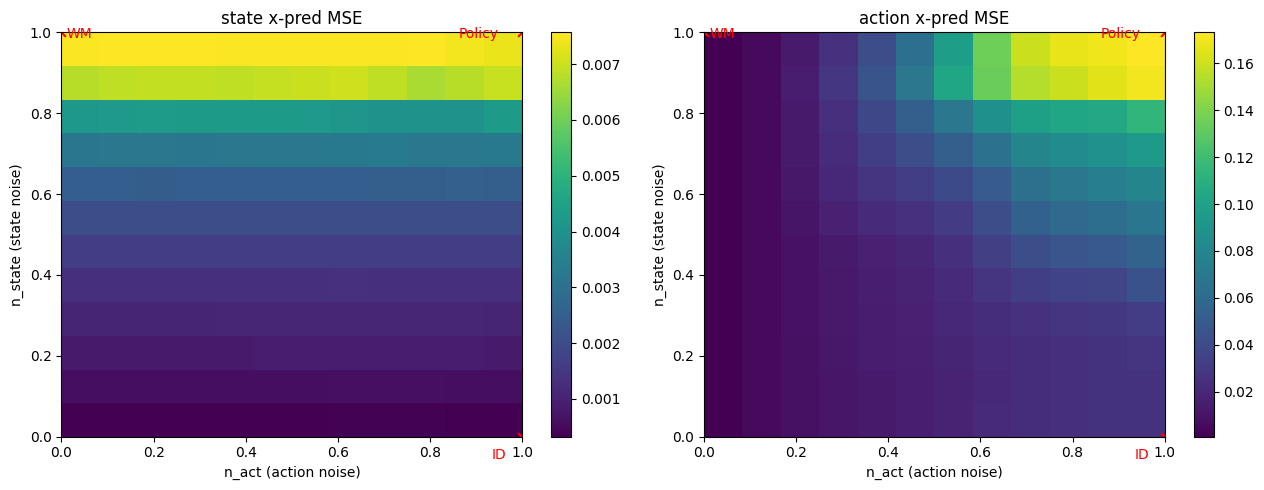

In [9]:
def plot_loss_heatmap(grid, n_act_grid, n_state_grid, title, ax):
    # grid is (G_act, G_state); we want n_act on x, n_state on y, origin at bottom-left.
    im = ax.imshow(
        grid.T.numpy(),
        origin='lower',
        extent=[min(n_act_grid), max(n_act_grid), min(n_state_grid), max(n_state_grid)],
        aspect='auto',
        cmap='viridis',
    )
    ax.set_xlabel('n_act (action noise)')
    ax.set_ylabel('n_state (state noise)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    # Annotate corners.
    ax.scatter([1.0, 0.0, 1.0], [0.0, 1.0, 1.0], c='red', s=40, marker='x')
    ax.annotate('ID', (1.0, 0.0), color='red', xytext=(-22, -16), textcoords='offset points')
    ax.annotate('WM', (0.0, 1.0), color='red', xytext=(4, -4), textcoords='offset points')
    ax.annotate('Policy', (1.0, 1.0), color='red', xytext=(-46, -4), textcoords='offset points')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_loss_heatmap(obs_grid, n_act_grid, n_state_grid, 'state x-pred MSE', axes[0])
plot_loss_heatmap(act_grid, n_act_grid, n_state_grid, 'action x-pred MSE', axes[1])
plt.tight_layout(); plt.show()

## Tier 1.b — θ-sweep rollouts

Five named points along the ray fan, each integrated all the way to clean. Same clean context across all five — only the ray angle θ changes.

Mapping (θ ∈ [0, π/2]):
- `θ = 0`     → (n_act=1, n_state=0)  — ID ray (action only)
- `θ = π/8`   → (cos π/8 ≈ 0.92, sin π/8 ≈ 0.38)
- `θ = π/4`   → (~0.71, ~0.71) — policy diagonal
- `θ = 3π/8`  → (~0.38, ~0.92)
- `θ = π/2`   → (0, 1) — WM ray (state only)

In [10]:
NUM_DIFFUSION_STEPS = 8
theta_values = [0.0, math.pi / 8, math.pi / 4, 3 * math.pi / 8, math.pi / 2]
theta_labels = ['ID (θ=0)', 'θ=π/8', 'policy (θ=π/4)', 'θ=3π/8', 'WM (θ=π/2)']

rollouts = []
for theta, label in zip(theta_values, theta_labels):
    n_act_start = math.cos(theta)
    n_state_start = math.sin(theta)
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        z_pred, a_pred = ray_sampler(
            denoiser,
            ctx_latents, ctx_actions,
            horizon_latents=hor_latents,
            horizon_actions=hor_actions,
            n_act_start=n_act_start,
            n_state_start=n_state_start,
            num_diffusion_steps=NUM_DIFFUSION_STEPS,
            is_horizon=make_is_horizon(T_ctx + T_hor, ctx_len=T_ctx, device=device),
        )
        with torch.no_grad():
            img_pred = tokenizer.decode(z_pred)
    rollouts.append({'label': label, 'theta': theta, 'n_act': n_act_start, 'n_state': n_state_start,
                     'img': img_pred, 'act': a_pred})
    print(f'{label}: n_act={n_act_start:.3f}, n_state={n_state_start:.3f}')

ID (θ=0): n_act=1.000, n_state=0.000
θ=π/8: n_act=0.924, n_state=0.383
policy (θ=π/4): n_act=0.707, n_state=0.707
θ=3π/8: n_act=0.383, n_state=0.924
WM (θ=π/2): n_act=0.000, n_state=1.000


ID (θ=0)


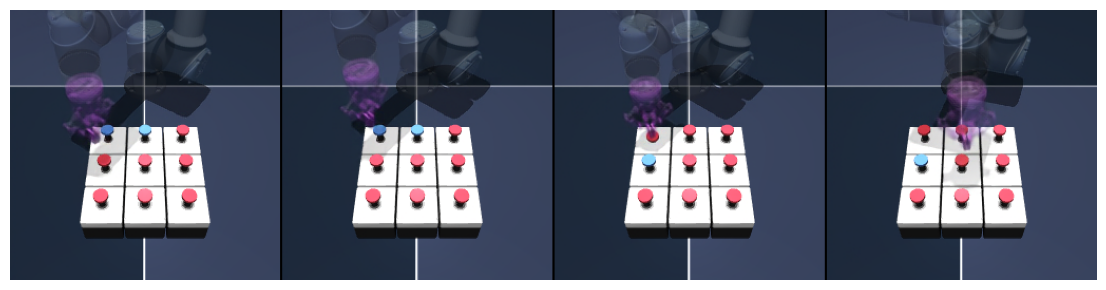

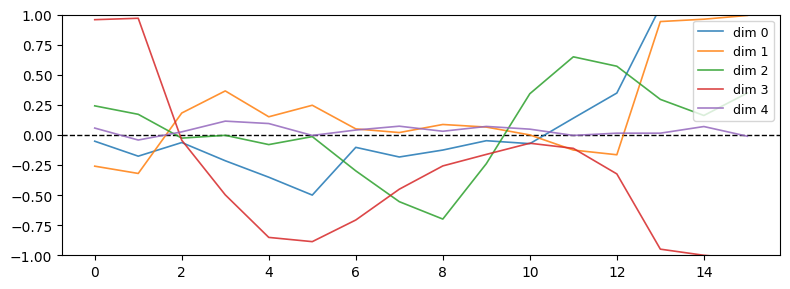

θ=π/8


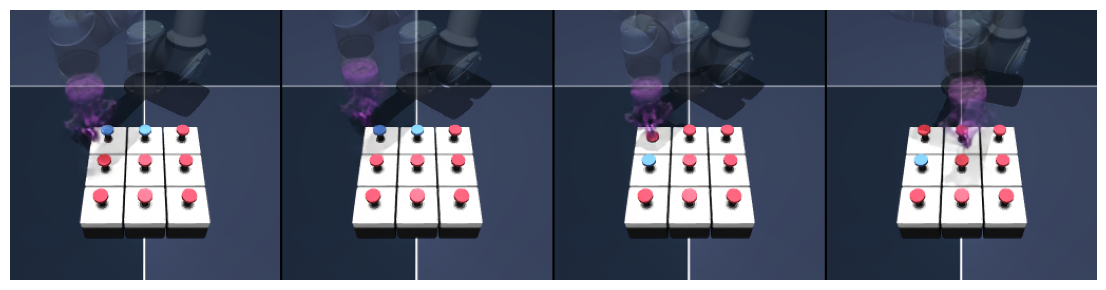

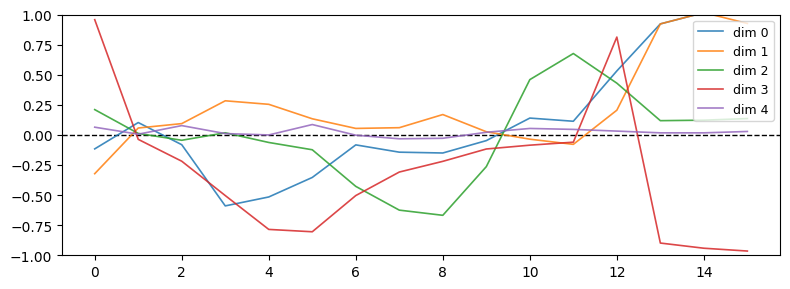

policy (θ=π/4)


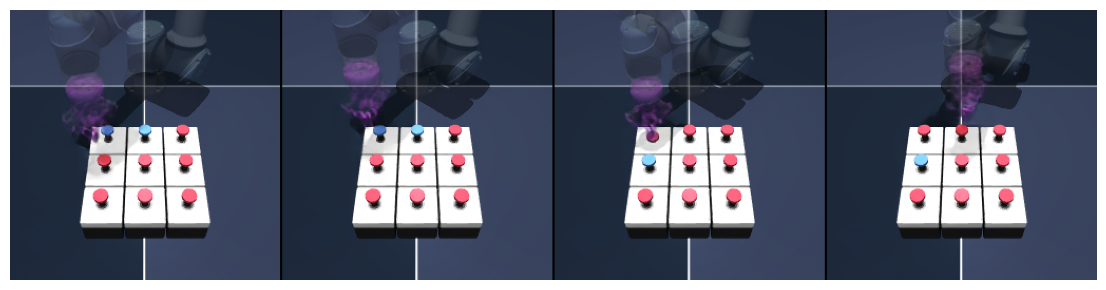

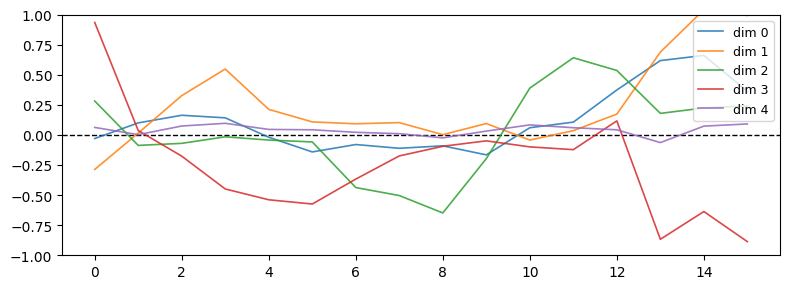

θ=3π/8


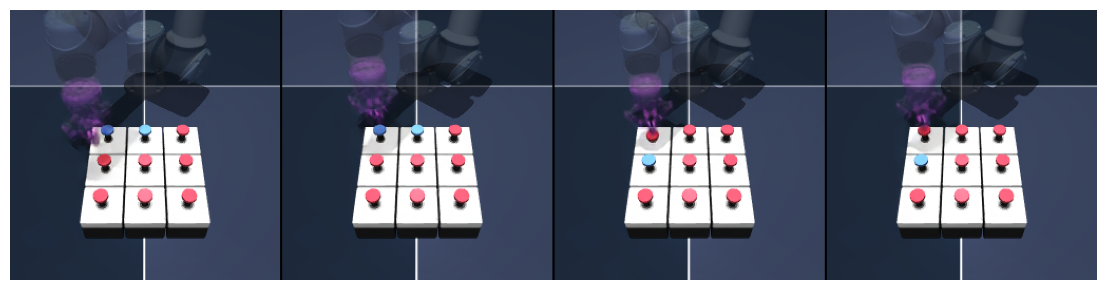

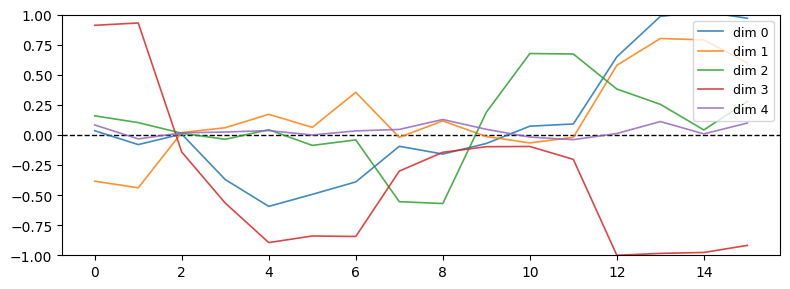

WM (θ=π/2)


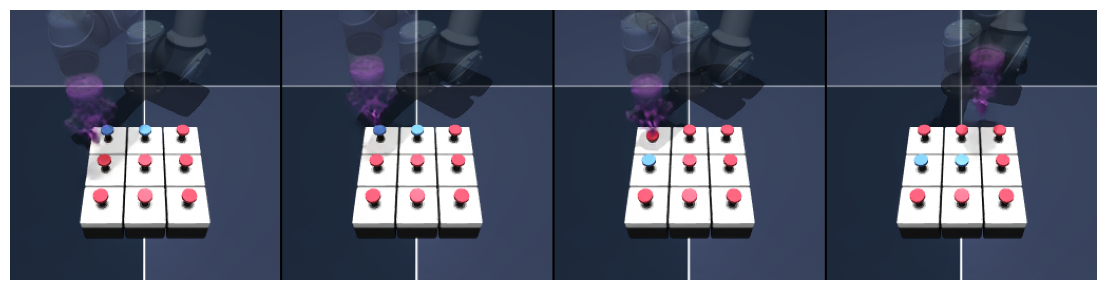

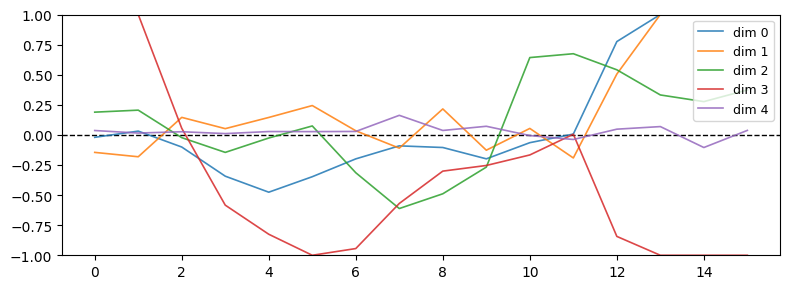

In [11]:
# Visualize each rollout: 4-frame snapshot strip + action plot.
for r in rollouts:
    print(r['label'])
    plotSnapshots(r['img'][0].to(torch.float32), n_frames=4)
    plotActions(r['act'][0])

In [11]:
# Quantitative: predicted vs ground-truth distance per modality, per θ.
# This is the integrated-trajectory analog of the loss heatmap.
print(f"{'mode':>18s}  {'state MSE':>10s}  {'action MSE':>10s}")
for r in rollouts:
    state_mse = (r['img'][0].float().cpu() - imgs[0, T_ctx:T_ctx + T_hor].float().cpu()).pow(2).mean().item()
    act_mse   = (r['act'][0].float().cpu() - hor_actions[0].float().cpu()).pow(2).mean().item()
    print(f"{r['label']:>18s}  {state_mse:>10.4f}  {act_mse:>10.4f}")

              mode   state MSE  action MSE
          ID (θ=0)      0.0001      0.0005
             θ=π/8      0.0005      0.0009
    policy (θ=π/4)      0.0007      0.0006
            θ=3π/8      0.0033      0.0043
        WM (θ=π/2)      0.0032      0.0000


## Tier 1.c — Mode 3 deep dive (random action proposer)

Start at the **policy corner** `(n_act=1, n_state=1)` with **fully bidirectional** attention (`is_horizon = ones`). Sample multiple rollouts from the same (noisy) context — they should land on diverse, plausible action trajectories.

Diversity metric: pairwise std of generated action trajectories across samples.

In [12]:
N_SAMPLES = 8
mode3_acts = []
mode3_imgs = []
is_horizon_full_bidir = make_is_horizon(T_ctx + T_hor, all_bidir=True, device=device)
for s in range(N_SAMPLES):
    torch.manual_seed(1000 + s)
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        z_pred, a_pred = ray_sampler(
            denoiser,
            ctx_latents, ctx_actions,
            horizon_latents=hor_latents,
            horizon_actions=hor_actions,
            n_act_start=1.0,
            n_state_start=1.0,
            num_diffusion_steps=NUM_DIFFUSION_STEPS,
            is_horizon=is_horizon_full_bidir,
        )
        with torch.no_grad():
            img_pred = tokenizer.decode(z_pred)
    mode3_acts.append(a_pred[0])
    mode3_imgs.append(img_pred[0])
mode3_acts = torch.stack(mode3_acts, dim=0)  # (N_SAMPLES, T_hor, n_act)
print('mode3_acts:', mode3_acts.shape)

mode3_acts: torch.Size([8, 16, 5])


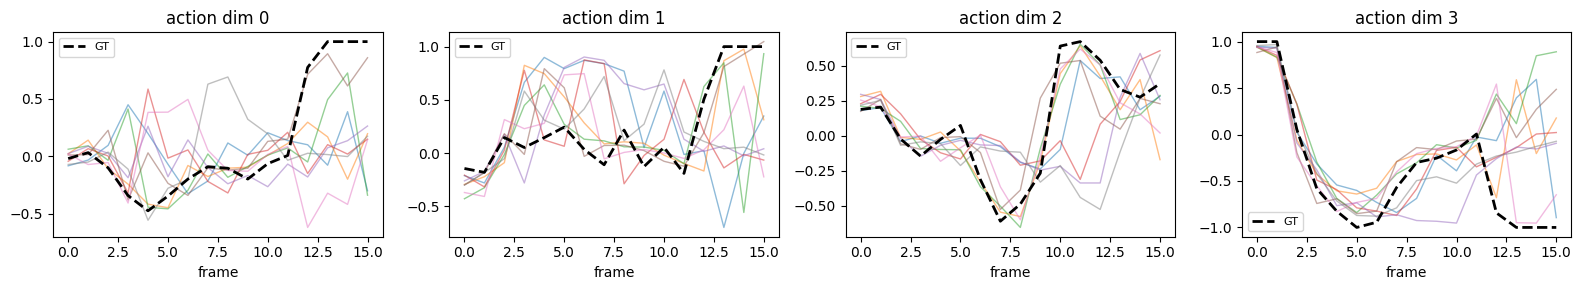

per-dim action std across samples (averaged over time):
  dim 0: 0.2554
  dim 1: 0.3141
  dim 2: 0.1844
  dim 3: 0.2523
  dim 4: 0.0350


In [13]:
# Action diversity: overlay all N samples on one axis, per action dim.
act_np = mode3_acts.cpu().float().numpy()
n_dim = act_np.shape[-1]
n_plot = min(n_dim, 4)
fig, axes = plt.subplots(1, n_plot, figsize=(4 * n_plot, 3))
if n_plot == 1:
    axes = [axes]
for d in range(n_plot):
    for s in range(N_SAMPLES):
        axes[d].plot(act_np[s, :, d], alpha=0.5, linewidth=1)
    axes[d].plot(hor_actions[0, :, d].cpu().float().numpy(), 'k--', linewidth=2, label='GT')
    axes[d].set_title(f'action dim {d}')
    axes[d].set_xlabel('frame')
    axes[d].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Pairwise std summary (per dim).
pair_std = mode3_acts.float().std(dim=0).mean(dim=0).cpu().numpy()  # (n_act,)
print('per-dim action std across samples (averaged over time):')
for d, s in enumerate(pair_std):
    print(f'  dim {d}: {s:.4f}')

mode-3 sample 0


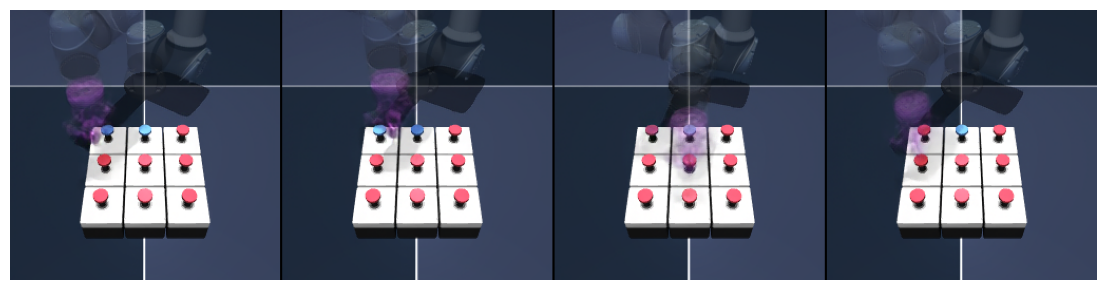

mode-3 sample 1


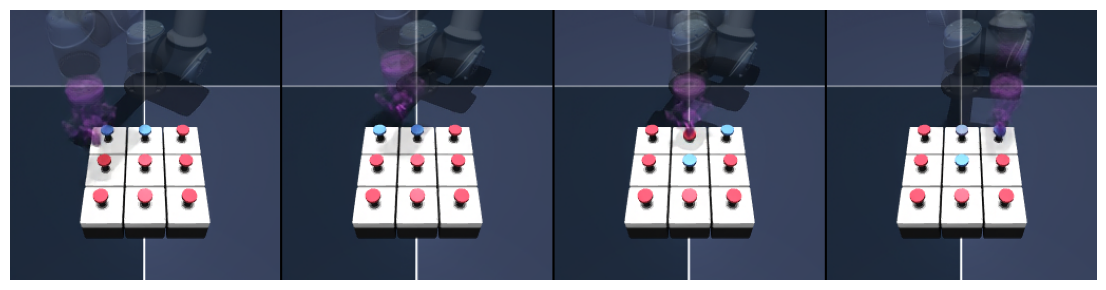

mode-3 sample 2


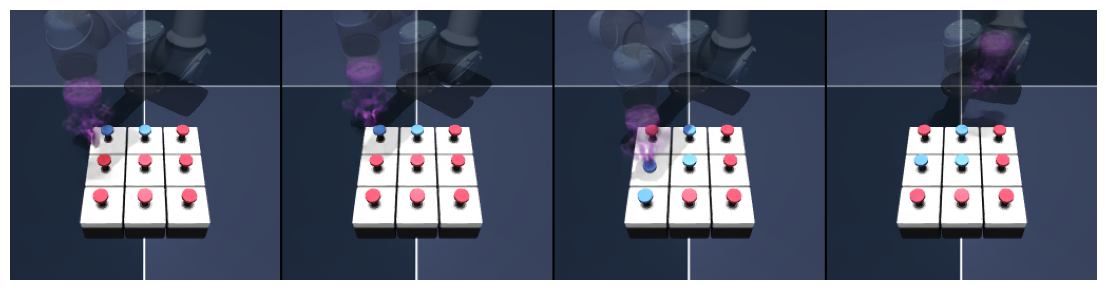

mode-3 sample 3


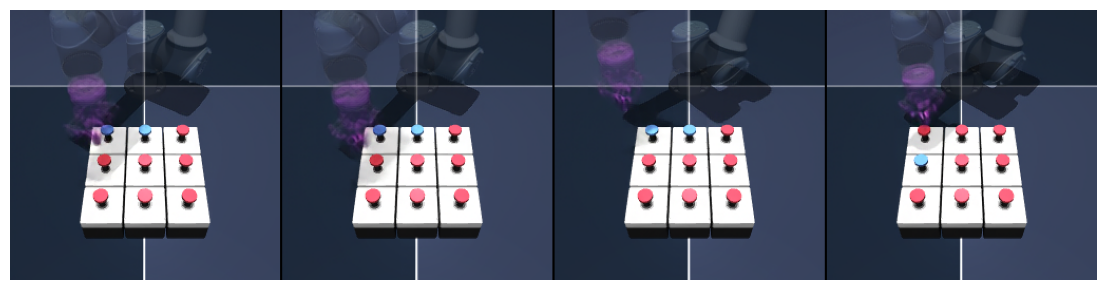

In [14]:
# Visual diversity: snapshot-strip per sample.
for s, img in enumerate(mode3_imgs[:4]):
    print(f'mode-3 sample {s}')
    plotSnapshots(img.to(torch.float32), n_frames=4)

In [15]:
# Visual diversity: snapshot-strip per sample.
for s, img in enumerate(mode3_imgs[:4]):
    print(f'mode-3 sample {s}')
    plotVideo(img.to(torch.float32))

mode-3 sample 0


This browser does not support the video tag.


mode-3 sample 1


This browser does not support the video tag.


mode-3 sample 2


This browser does not support the video tag.


mode-3 sample 3


This browser does not support the video tag.


## Tier 1.d — Horizon-aware attention ablation

Same input through three `is_horizon` settings:
- **All-causal**: legacy causal-only attention.
- **Step** (default): causal-into-ctx + bidirectional-within-horizon.
- **All-bidir**: every frame attends to every other frame (mode-3 setting).

Probe at the policy corner `(1, 1)` — where bidir attention has the most room to help.

In [16]:
settings = {
    'all_causal': make_is_horizon(T_ctx + T_hor, all_causal=True, device=device),
    'step':       make_is_horizon(T_ctx + T_hor, ctx_len=T_ctx, device=device),
    'all_bidir':  make_is_horizon(T_ctx + T_hor, all_bidir=True, device=device),
}

results = {}
for name, ih in settings.items():
    torch.manual_seed(42)  # same noise across settings
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        z_pred, a_pred = ray_sampler(
            denoiser,
            ctx_latents, ctx_actions,
            horizon_latents=hor_latents,
            horizon_actions=hor_actions,
            n_act_start=1.0,
            n_state_start=1.0,
            num_diffusion_steps=NUM_DIFFUSION_STEPS,
            is_horizon=ih,
        )
    state_mse = (z_pred[0].float().cpu() - hor_latents[0].float().cpu()).pow(2).mean().item()
    act_mse   = (a_pred[0].float().cpu() - hor_actions[0].float().cpu()).pow(2).mean().item()
    results[name] = {'z': z_pred, 'a': a_pred, 'state_mse': state_mse, 'act_mse': act_mse}
    print(f'{name:>10s}  state_mse={state_mse:.4f}  act_mse={act_mse:.4f}')

all_causal  state_mse=0.0129  act_mse=0.1837
      step  state_mse=0.0129  act_mse=0.1837
 all_bidir  state_mse=0.0129  act_mse=0.1837


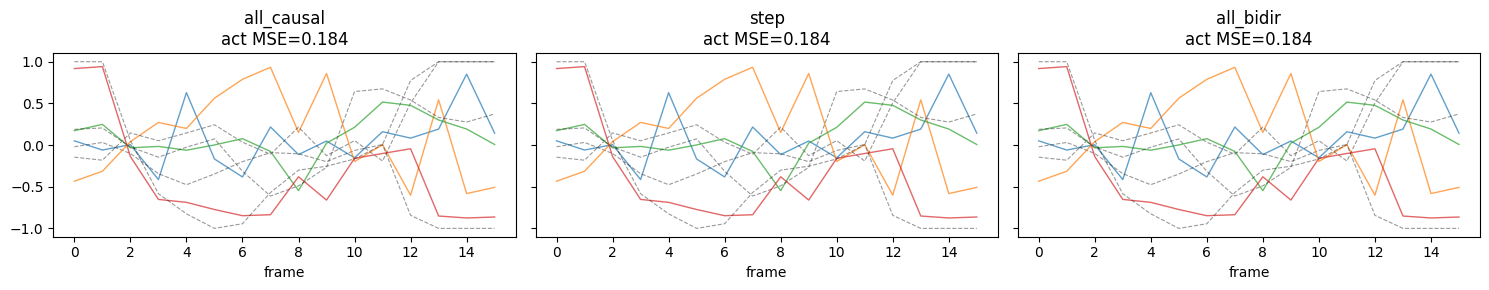

In [17]:
# Side-by-side action overlay for the three settings.
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)
for ax, (name, r) in zip(axes, results.items()):
    act = r['a'][0].cpu().float().numpy()
    gt = hor_actions[0].cpu().float().numpy()
    for d in range(min(act.shape[-1], 4)):
        ax.plot(act[:, d], alpha=0.7, linewidth=1)
        ax.plot(gt[:, d], 'k--', alpha=0.4, linewidth=0.8)
    ax.set_title(f'{name}\nact MSE={r["act_mse"]:.3f}')
    ax.set_xlabel('frame')
plt.tight_layout(); plt.show()

## Tier 2 — Named-mode rollouts under the new sampler

Replicates the WM / ID / policy patterns from `g1-sampling.ipynb`, routed through `ray_sampler` so `is_horizon` is plumbed correctly and the horizon_aware mask path is active. Each named mode is just a different choice of `(n_act_start, n_state_start)`:

| Mode | n_act_start | n_state_start | What's given clean | What we predict |
|---|---|---|---|---|
| WM | 0 | 1 | future actions | future state |
| ID | 1 | 0 | future state | future actions |
| Policy | 1 | 1 | (none) | joint future state + action |

### 2.a — World model (clean future actions known)

`n_act_start = 0` holds the action stream at the known clean signal throughout — the model only integrates state. The step-shaped `is_horizon` makes the context causal and the horizon block bidirectional.

WM state MSE: 0.0152


This browser does not support the video tag.


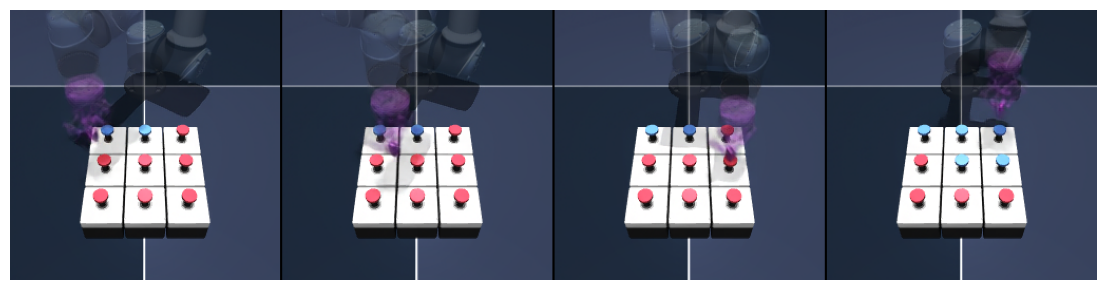

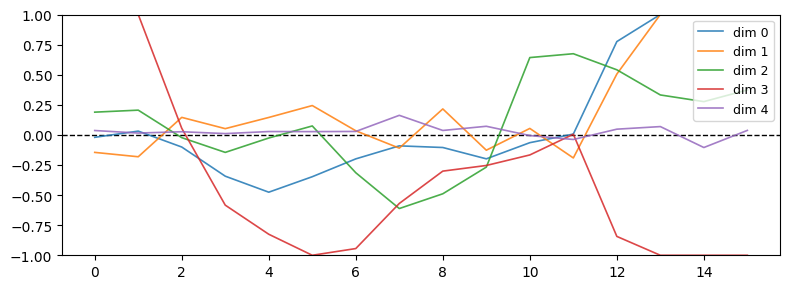

In [18]:
hor_actions_wm = hor_actions.clone()
# hor_actions_wm[:] = 0
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    z_wm, a_wm = ray_sampler(
        denoiser,
        ctx_latents, ctx_actions,
        horizon_latents=hor_latents,
        horizon_actions=hor_actions_wm,
        n_act_start=0.0,
        n_state_start=1.0,
        num_diffusion_steps=NUM_DIFFUSION_STEPS,
        is_horizon=make_is_horizon(T_ctx + T_hor, ctx_len=T_ctx, device=device),
    )
    with torch.no_grad():
        img_wm = tokenizer.decode(z_wm)
state_mse_wm = (z_wm[0].float().cpu() - hor_latents[0].float().cpu()).pow(2).mean().item()
print(f'WM state MSE: {state_mse_wm:.4f}')
plotVideo(img_wm[0].to(torch.float32))
plotSnapshots(img_wm[0].to(torch.float32), n_frames=4)
plotActions(a_wm[0])  # held at the clean ground truth

### 2.b — Inverse dynamics (clean state known)

`n_state_start = 0` holds state at the known clean signal — the model only integrates the action stream, inferring what actions produced the observed transitions.

ID action MSE: 0.0516


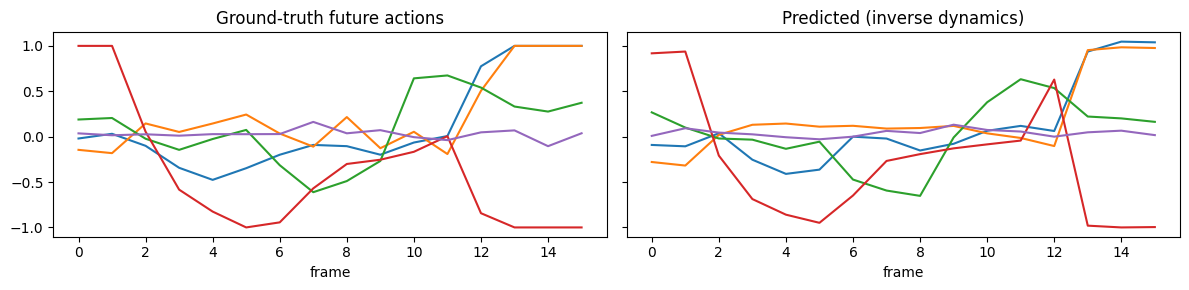

In [19]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    z_id, a_id = ray_sampler(
        denoiser,
        ctx_latents, ctx_actions,
        horizon_latents=hor_latents,
        horizon_actions=hor_actions,
        n_act_start=1.0,
        n_state_start=0.0,
        num_diffusion_steps=NUM_DIFFUSION_STEPS,
        is_horizon=make_is_horizon(T_ctx + T_hor, ctx_len=T_ctx, device=device),
    )
act_mse_id = (a_id[0].float().cpu() - hor_actions[0].float().cpu()).pow(2).mean().item()
print(f'ID action MSE: {act_mse_id:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
axes[0].set_title('Ground-truth future actions')
axes[0].plot(hor_actions[0].cpu().float().numpy())
axes[0].set_xlabel('frame')
axes[1].set_title('Predicted (inverse dynamics)')
axes[1].plot(a_id[0].cpu().float().numpy())
axes[1].set_xlabel('frame')
plt.tight_layout(); plt.show()

### 2.c — Policy (joint state + action generation)

Start at the policy corner `(1, 1)` — pure noise on both modalities — and integrate jointly. Step-shaped `is_horizon` keeps the clean context causal-only.

Policy state MSE: 0.0130  action MSE: 0.2442


This browser does not support the video tag.


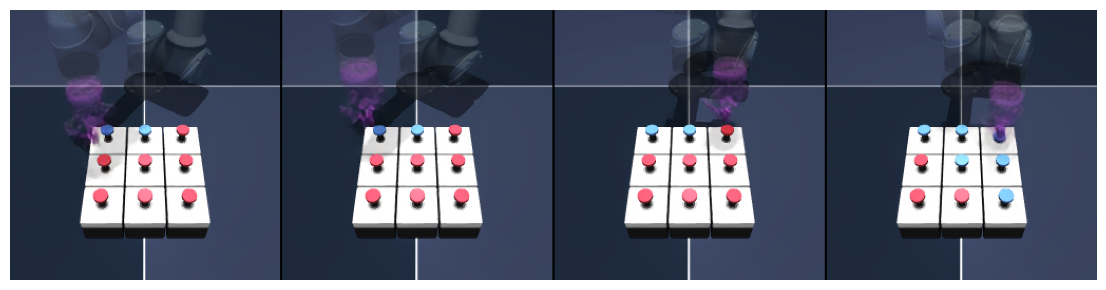

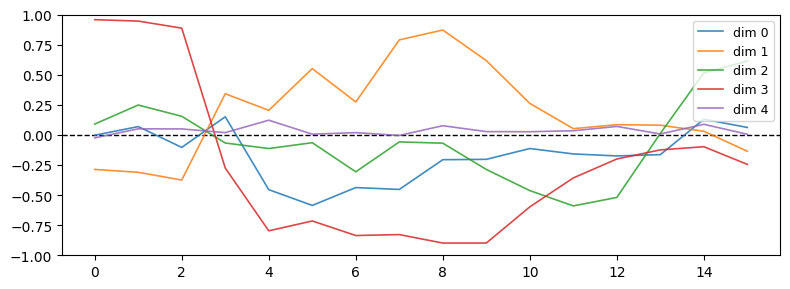

In [20]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    z_pol, a_pol = ray_sampler(
        denoiser,
        ctx_latents, ctx_actions,
        horizon_latents=hor_latents,
        horizon_actions=hor_actions,
        n_act_start=1.0,
        n_state_start=1.0,
        num_diffusion_steps=NUM_DIFFUSION_STEPS,
        context_cond_tau=0.9,
        is_horizon=make_is_horizon(T_ctx + T_hor, ctx_len=T_ctx, device=device, all_bidir=True),
    )
    with torch.no_grad():
        img_pol = tokenizer.decode(z_pol)
state_mse_pol = (z_pol[0].float().cpu() - hor_latents[0].float().cpu()).pow(2).mean().item()
act_mse_pol   = (a_pol[0].float().cpu() - hor_actions[0].float().cpu()).pow(2).mean().item()
print(f'Policy state MSE: {state_mse_pol:.4f}  action MSE: {act_mse_pol:.4f}')
plotVideo(img_pol[0].to(torch.float32))
plotSnapshots(img_pol[0].to(torch.float32), n_frames=4)
plotActions(a_pol[0])

### 2.d — Per-mode summary

Quantitative comparison against ground truth on this single held-out window. (For a robust eval, aggregate across a batch of val windows; this is the diagnostic single-sample version.)

Expected pattern: WM state MSE and ID action MSE should be small (clean conditioning is informative). Policy MSEs are upper bounds since the model has no future signal to anchor to.

In [21]:
rows = [
    ('WM',     0.0, 1.0, state_mse_wm,  None),
    ('ID',     1.0, 0.0, None,          act_mse_id),
    ('Policy', 1.0, 1.0, state_mse_pol, act_mse_pol),
]
print(f"{'mode':>8s}  {'n_act':>6s}  {'n_state':>8s}  {'state MSE':>10s}  {'action MSE':>10s}")
for name, na, ns, smse, amse in rows:
    s = f'{smse:.4f}' if smse is not None else '   —  '
    a = f'{amse:.4f}' if amse is not None else '   —  '
    print(f'{name:>8s}  {na:>6.1f}  {ns:>8.1f}  {s:>10s}  {a:>10s}')

    mode   n_act   n_state   state MSE  action MSE
      WM     0.0       1.0      0.0152         —  
      ID     1.0       0.0         —        0.0516
  Policy     1.0       1.0      0.0130      0.2442


## Tier 3 — Pretraining marginals (right edge + top edge)

Multi-frame inference protocols matching what `VideoPretrainingForwardProcess` and `ActionPretrainingForwardProcess` train. Each protocol has one modality permanently at pure noise (no integration) while the other modality varies per frame (Diffusion Forcing) and integrates to clean:

| Section | Right/Top | Active modality | Held at noise |
|---|---|---|---|
| 3.a | right edge (`n_act=1`)   | state  | action |
| 3.b | top edge (`n_state=1`)   | action | state  |

Use `marginal_state_sampler` / `marginal_action_sampler` from `sampling_new.py` — they handle the "hold at noise" behavior that `ray_sampler` doesn't (`ray_sampler` only supports "integrate from n_start" or "hold clean").

### 3.a — Video pretraining inference (right edge)

State varies per frame (linear ramp by default); action is pure noise throughout. The action stream input is random and uninformative — the model's action prediction is unconstrained (no training gradient on that path), so we ignore the returned action and look only at state quality.

Video-pretraining state MSE: 0.0035


This browser does not support the video tag.


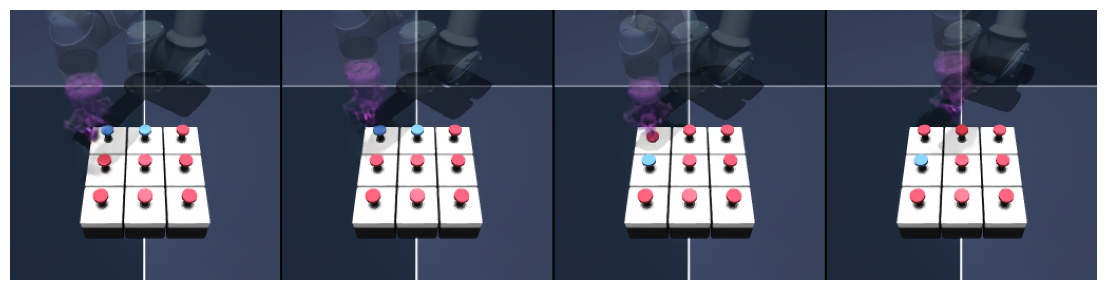

In [22]:
from dreamerv4uwm.sampling_new import marginal_state_sampler

# Per-frame state noise ramp: cleaner at frame 0, noisier at frame T_hor-1.
n_state_pf_vid = torch.linspace(0.2, 1.0, T_hor)

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    z_vid, _ = marginal_state_sampler(
        denoiser,
        ctx_latents, ctx_actions,
        horizon_latents=hor_latents,
        horizon_actions=hor_actions,
        n_state_start_per_frame=n_state_pf_vid,
        num_diffusion_steps=NUM_DIFFUSION_STEPS,
        # Match training: video_pretraining uses 50/50 causal vs bidir per batch.
        # For diagnostic, default step-shape (causal-into-ctx + bidir-in-horizon).
        is_horizon=make_is_horizon(T_ctx + T_hor, ctx_len=T_ctx, device=device),
    )
    with torch.no_grad():
        img_vid = tokenizer.decode(z_vid)

state_mse_vid = (z_vid[0].float().cpu() - hor_latents[0].float().cpu()).pow(2).mean().item()
print(f'Video-pretraining state MSE: {state_mse_vid:.4f}')
plotVideo(img_vid[0].to(torch.float32))
plotSnapshots(img_vid[0].to(torch.float32), n_frames=4)

In [23]:
# Compare same protocol with all-bidir is_horizon (matches the bidir half of
# training's coin flip) vs all-causal (the streaming-compatible half).
settings = {
    'all_causal': make_is_horizon(T_ctx + T_hor, all_causal=True, device=device),
    'all_bidir':  make_is_horizon(T_ctx + T_hor, all_bidir=True,  device=device),
}
for name, ih in settings.items():
    torch.manual_seed(0)
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        z_v, _ = marginal_state_sampler(
            denoiser,
            ctx_latents, ctx_actions,
            horizon_latents=hor_latents,
            horizon_actions=hor_actions,
            n_state_start_per_frame=n_state_pf_vid,
            num_diffusion_steps=NUM_DIFFUSION_STEPS,
            is_horizon=ih,
        )
    mse = (z_v[0].float().cpu() - hor_latents[0].float().cpu()).pow(2).mean().item()
    print(f'  is_horizon={name:>11s}  state MSE={mse:.4f}')

  is_horizon= all_causal  state MSE=0.0039
  is_horizon=  all_bidir  state MSE=0.0039


### 3.b — Action pretraining inference (top edge)

Symmetric to 3.a: action varies per frame, state is pure noise throughout. This generates an *action prior* — what actions the model believes are plausible given no state context.

Two views: (i) one trajectory plotted vs ground truth; (ii) multiple seeded samples overlaid to visualize the marginal action distribution.

Action-pretraining action MSE vs GT: 0.1434


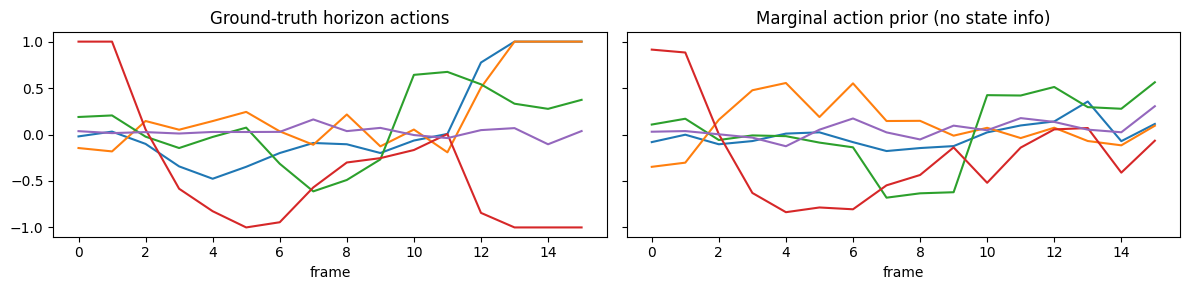

In [24]:
from dreamerv4uwm.sampling_new import marginal_action_sampler

n_act_pf_marginal = torch.linspace(0.2, 1.0, T_hor)

torch.manual_seed(0)
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    _, a_marg = marginal_action_sampler(
        denoiser,
        ctx_latents, ctx_actions,
        horizon_latents=hor_latents,
        horizon_actions=hor_actions,
        n_act_start_per_frame=n_act_pf_marginal,
        num_diffusion_steps=NUM_DIFFUSION_STEPS,
        is_horizon=make_is_horizon(T_ctx + T_hor, ctx_len=T_ctx, device=device),
    )

act_mse_marg = (a_marg[0].float().cpu() - hor_actions[0].float().cpu()).pow(2).mean().item()
print(f'Action-pretraining action MSE vs GT: {act_mse_marg:.4f}')

# Single-trajectory plot vs GT.
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
axes[0].set_title('Ground-truth horizon actions')
axes[0].plot(hor_actions[0].cpu().float().numpy()); axes[0].set_xlabel('frame')
axes[1].set_title('Marginal action prior (no state info)')
axes[1].plot(a_marg[0].cpu().float().numpy()); axes[1].set_xlabel('frame')
plt.tight_layout(); plt.show()

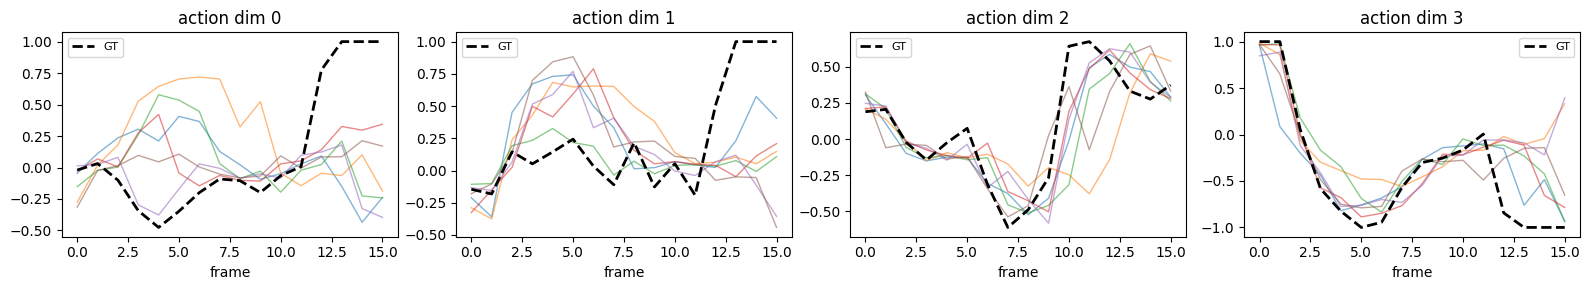

per-dim action-prior std across samples (averaged over frames):
  dim 0: 0.2088
  dim 1: 0.1607
  dim 2: 0.1345
  dim 3: 0.1835
  dim 4: 0.0344


In [25]:
# Multiple seeded samples to inspect the marginal action distribution.
N_MARG_SAMPLES = 6
marg_samples = []
for s in range(N_MARG_SAMPLES):
    torch.manual_seed(2000 + s)
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        _, a_s = marginal_action_sampler(
            denoiser,
            ctx_latents, ctx_actions,
            horizon_latents=hor_latents,
            horizon_actions=hor_actions,
            n_act_start_per_frame=1.0,  # constant full-noise start (mirrors mode-3 use)
            num_diffusion_steps=NUM_DIFFUSION_STEPS,
            is_horizon=make_is_horizon(T_ctx + T_hor, all_bidir=True, device=device),
        )
    marg_samples.append(a_s[0])
marg_samples = torch.stack(marg_samples, dim=0)  # (N, T_hor, n_act)

act_np = marg_samples.cpu().float().numpy()
n_dim = act_np.shape[-1]
n_plot = min(n_dim, 4)
fig, axes = plt.subplots(1, n_plot, figsize=(4 * n_plot, 3))
if n_plot == 1: axes = [axes]
for d in range(n_plot):
    for s in range(N_MARG_SAMPLES):
        axes[d].plot(act_np[s, :, d], alpha=0.55, linewidth=1)
    axes[d].plot(hor_actions[0, :, d].cpu().float().numpy(), 'k--', linewidth=2, label='GT')
    axes[d].set_title(f'action dim {d}')
    axes[d].set_xlabel('frame')
    axes[d].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Per-dim std across samples (averaged over frames).
pair_std = marg_samples.float().std(dim=0).mean(dim=0).cpu().numpy()
print('per-dim action-prior std across samples (averaged over frames):')
for d, s in enumerate(pair_std):
    print(f'  dim {d}: {s:.4f}')

## Tier 4 — Inference-protocol comparisons

Two comparisons here:

- **4.a — Streaming vs chunk.** The cached `AutoRegressiveForwardDynamics` (from the legacy `sampling.py`) generates one frame at a time with purely causal attention. `ray_sampler` runs the same start point as one uncached chunk with bidirectional attention available inside the horizon block. Same context → compare quality and wall-clock time.
- **4.b — Progressive r-profile rollout.** Each horizon frame starts at its own noise level (linear ramp); each frame integrates its own ray to clean over the same K Euler steps. Mirrors training's `progressive` r-profile.

Note: `AutoRegressiveForwardDynamics` in `sampling.py` predates `horizon_aware` and does not thread `is_horizon` through `forward_step`. Since the cached path is causal-only by construction, the `frame_id_embedder` contribution is silently skipped — slightly off-distribution but consistent with the cached-path design.

### 4.a — Streaming vs chunk at the policy corner

Both protocols start at `(n_act=1, n_state=1)`. Streaming uses KV-cached causal attention; chunk allows bidirectional attention within the horizon block (via step-shaped `is_horizon`).

In [30]:
import time
from dreamerv4uwm.sampling import AutoRegressiveForwardDynamics

T_hor_t4 = T_hor
imgs_ctx_pix = imgs[:, :T_ctx]

# --- Streaming (causal, KV-cached, frame-by-frame) ---
ar = AutoRegressiveForwardDynamics(
    denoiser=denoiser, tokenizer=tokenizer,
    mode='policy',
    context_length=cfg.denoiser.context_length,
    max_forward_steps=T_ctx + T_hor_t4 + 4,
    context_cond_tau=0.99,
    denoising_step_count=NUM_DIFFUSION_STEPS,
    device=device,
    dtype=torch.float32,
)
torch.manual_seed(0)
t0 = time.time()
stream_imgs_l, stream_acts_l = [], []
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    ar.reset(imgs_ctx_pix, ctx_actions)
    for t in range(T_hor_t4):
        img_t, act_t = ar.step()
        stream_imgs_l.append(img_t.detach())
        stream_acts_l.append(act_t.detach())
stream_time = time.time() - t0
stream_imgs = torch.stack(stream_imgs_l, dim=1)  # (B, T_hor, C, H, W)
stream_acts = torch.stack(stream_acts_l, dim=1)  # (B, T_hor, n_act)

# --- Chunk (uncached, bidir within horizon) ---
torch.manual_seed(0)
t0 = time.time()
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    z_chunk, a_chunk = ray_sampler(
        denoiser,
        ctx_latents, ctx_actions,
        horizon_latents=hor_latents,
        horizon_actions=hor_actions,
        n_act_start=1.0,
        n_state_start=1.0,
        num_diffusion_steps=NUM_DIFFUSION_STEPS,
        is_horizon=make_is_horizon(T_ctx + T_hor_t4, ctx_len=T_ctx, device=device),
    )
chunk_time = time.time() - t0

# Encode streaming pixels back to latent for a fair latent-space MSE.
with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        stream_latents = tokenizer.encode(stream_imgs.to(device))

stream_state_mse = (stream_latents.float().cpu() - hor_latents.float().cpu()).pow(2).mean().item()
chunk_state_mse  = (z_chunk.float().cpu()         - hor_latents.float().cpu()).pow(2).mean().item()
stream_act_mse   = (stream_acts.float().cpu()     - hor_actions.float().cpu()).pow(2).mean().item()
chunk_act_mse    = (a_chunk.float().cpu()         - hor_actions.float().cpu()).pow(2).mean().item()

print(f"{'protocol':>10s}  {'state MSE':>10s}  {'action MSE':>10s}  {'wall time':>10s}")
print(f'{"streaming":>10s}  {stream_state_mse:>10.4f}  {stream_act_mse:>10.4f}  {stream_time:>9.2f}s')
print(f'{"chunk":>10s}  {chunk_state_mse:>10.4f}  {chunk_act_mse:>10.4f}  {chunk_time:>9.2f}s')

  protocol   state MSE  action MSE   wall time
 streaming      0.0123      0.3261       2.66s
     chunk      0.0123      0.1931       0.66s


Streaming rollout:


This browser does not support the video tag.


Chunk rollout:


This browser does not support the video tag.


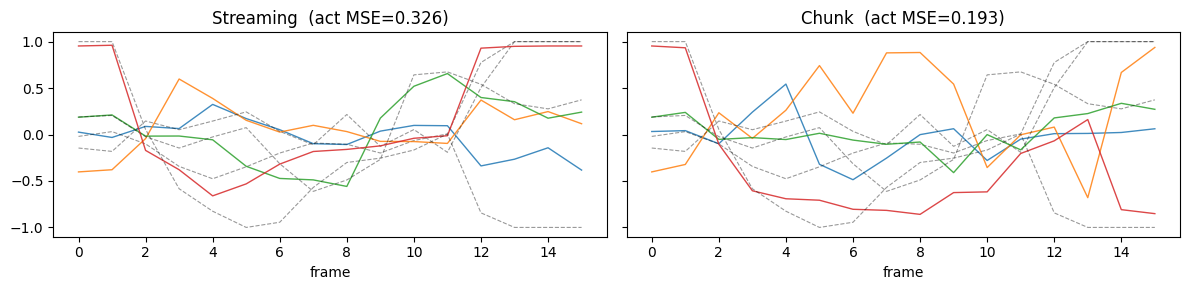

In [31]:
# Side-by-side visualization of the two rollouts.
print('Streaming rollout:')
# plotSnapshots(stream_imgs[0].to(torch.float32), n_frames=4)
plotVideo(stream_imgs[0].to(torch.float32))
with torch.no_grad():
    chunk_imgs = tokenizer.decode(z_chunk)
print('Chunk rollout:')
# plotSnapshots(chunk_imgs[0].to(torch.float32), n_frames=4)
plotVideo(chunk_imgs[0].to(torch.float32))

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
n_dim_plot = min(stream_acts.shape[-1], 4)
axes[0].set_title(f'Streaming  (act MSE={stream_act_mse:.3f})')
for d in range(n_dim_plot):
    axes[0].plot(stream_acts[0, :, d].cpu().float().numpy(), alpha=0.85, linewidth=1)
    axes[0].plot(hor_actions[0, :, d].cpu().float().numpy(), 'k--', alpha=0.4, linewidth=0.8)
axes[0].set_xlabel('frame')
axes[1].set_title(f'Chunk  (act MSE={chunk_act_mse:.3f})')
for d in range(n_dim_plot):
    axes[1].plot(a_chunk[0, :, d].cpu().float().numpy(), alpha=0.85, linewidth=1)
    axes[1].plot(hor_actions[0, :, d].cpu().float().numpy(), 'k--', alpha=0.4, linewidth=0.8)
axes[1].set_xlabel('frame')
plt.tight_layout(); plt.show()

### 4.b — Progressive r-profile rollout

Per-frame starting noise level ramps linearly from `r_min` (frame 0, cleanest) to `r_max` (frame `T_hor-1`, noisiest). Each frame integrates its own ray to clean in `NUM_DIFFUSION_STEPS` Euler steps. `is_horizon` is `zeros(T_total)` to match how progressive was trained (all-causal attention).

Progressive rollout: state MSE=0.0239  action MSE=0.0033


This browser does not support the video tag.


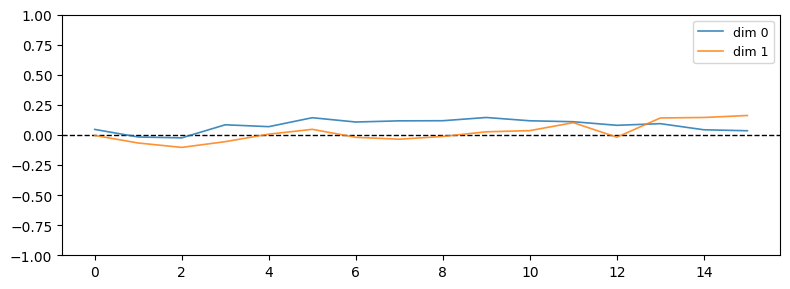

In [77]:
from dreamerv4uwm.sampling_new import progressive_ray_sampler

r_min, r_max = 0.1, 1.0
n_state_pf = torch.linspace(r_min, r_max, T_hor)
n_act_pf   = torch.linspace(r_min, r_max, T_hor)

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    z_prog, a_prog = progressive_ray_sampler(
        denoiser,
        ctx_latents, ctx_actions,
        horizon_latents=hor_latents,
        horizon_actions=hor_actions,
        n_act_start_per_frame=n_act_pf,
        n_state_start_per_frame=n_state_pf,
        num_diffusion_steps=NUM_DIFFUSION_STEPS,
        is_horizon=make_is_horizon(T_ctx + T_hor, all_causal=True, device=device),
    )
    with torch.no_grad():
        img_prog = tokenizer.decode(z_prog)

state_mse_prog = (z_prog[0].float().cpu() - hor_latents[0].float().cpu()).pow(2).mean().item()
act_mse_prog   = (a_prog[0].float().cpu() - hor_actions[0].float().cpu()).pow(2).mean().item()
print(f'Progressive rollout: state MSE={state_mse_prog:.4f}  action MSE={act_mse_prog:.4f}')
# plotSnapshots(img_prog[0].to(torch.float32), n_frames=4)
plotVideo(img_prog[0])
plotActions(a_prog[0])

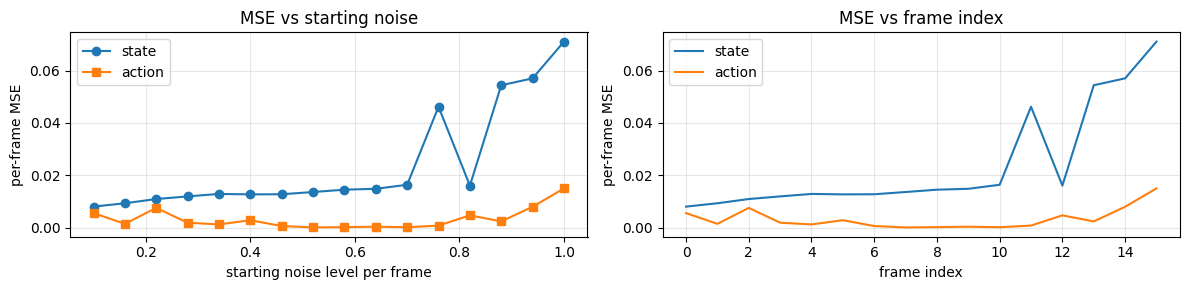

In [78]:
# Per-frame error vs starting noise — diagnostic: does error scale with the
# starting noise level the model was asked to handle?
per_frame_state = (z_prog[0].float().cpu() - hor_latents[0].float().cpu()).pow(2).mean(dim=(-1, -2)).numpy()
per_frame_act   = (a_prog[0].float().cpu() - hor_actions[0].float().cpu()).pow(2).mean(dim=-1).numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(n_state_pf.numpy(), per_frame_state, 'o-', label='state')
axes[0].plot(n_act_pf.numpy(),   per_frame_act,   's-', label='action')
axes[0].set_xlabel('starting noise level per frame')
axes[0].set_ylabel('per-frame MSE')
axes[0].set_title('MSE vs starting noise')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(per_frame_state, label='state')
axes[1].plot(per_frame_act,   label='action')
axes[1].set_xlabel('frame index')
axes[1].set_ylabel('per-frame MSE')
axes[1].set_title('MSE vs frame index')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## Next steps (Tier 5)

Still pending:
- Tier 5: quantitative summary table aggregating MSE / diversity / reward metrics across a batch of val windows (instead of the single window used through Tiers 1-4).